In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt




In [5]:
df = pd.read_csv("Titanic-Dataset.csv")
print("File read sucessfully", df.head)
    

File read sucessfully <bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..               

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df['Age'].fillna(df['Age'].median(),inplace=True)

In [18]:
df.drop(columns=['Cabin'], inplace=True)

In [11]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)   

C:\Users\bhava\AppData\Local\Temp\ipykernel_19848\1936118036.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

Median
PassengerId    446.000000
Survived         0.000000
Pclass           3.000000
Age             29.699118
SibSp            0.000000
Parch            0.000000
Fare            14.454200
dtype: float64

Standard Deviation
PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             13.002015
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64


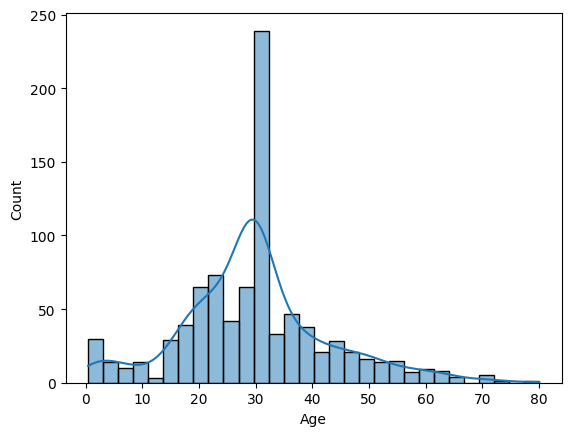

In [29]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.show()

1. Histogram of Age

Inference:

Most passengers were between 20 and 40 years old.
There were fewer children and elderly passengers.

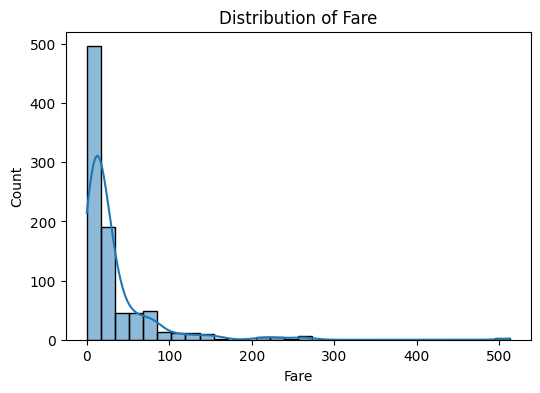

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

Histogram of Fare

Inference:

Most passengers paid lower fares.
Only a small number of passengers paid very high fares, making the distribution right-skewed.

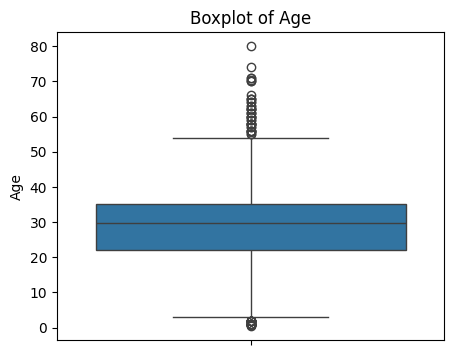

In [32]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Age'])

plt.title("Boxplot of Age")

plt.show()

Boxplot of Age

Inference:

The Age feature has a few outliers, representing passengers who were much older than the majority.

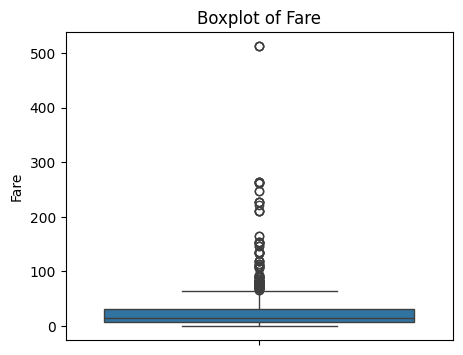

In [33]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Fare'])

plt.title("Boxplot of Fare")

plt.show()

Boxplot of Fare

Inference:

The Fare feature contains several outliers, indicating that a few passengers paid significantly higher ticket prices than others.

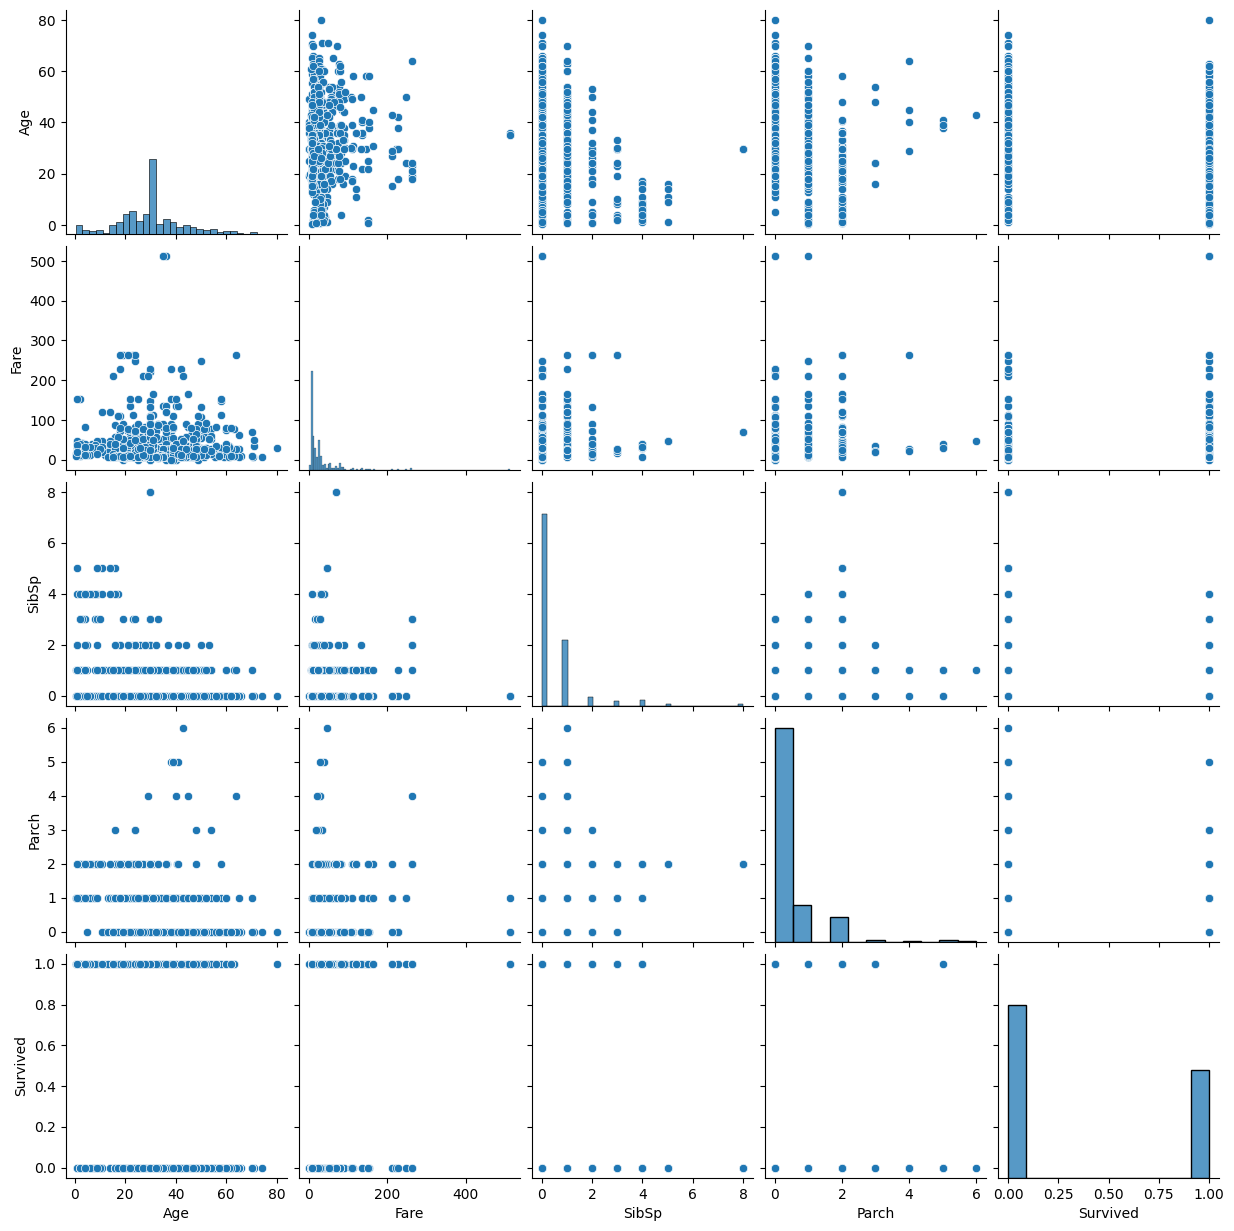

In [34]:
sns.pairplot(df[['Age','Fare','SibSp','Parch','Survived']])

plt.show()

Pairplot

Inference:

There is no strong linear relationship between most numerical features.
Passengers with higher fares tend to belong to higher passenger classes.

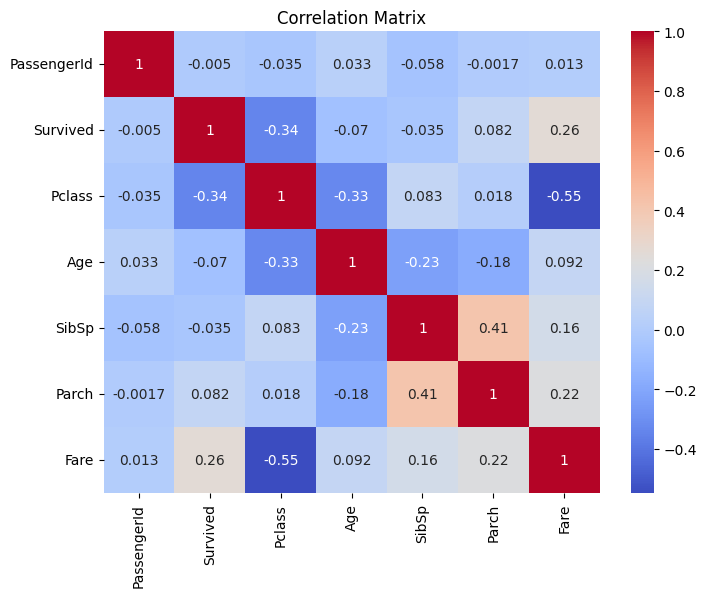

In [35]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

Correlation Matrix

Inference:

Most numerical features have weak to moderate correlations.
Fare and Pclass show a negative correlation, indicating that first-class passengers generally paid higher fares.

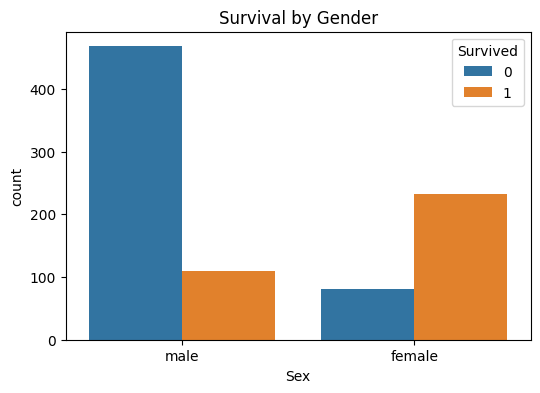

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

Survival by Gender (Countplot)

Inference:

Female passengers had a higher survival rate compared to male passengers.